<a href="https://colab.research.google.com/github/ASteve29/Machine-Learning/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression From Scratch

Goal:
- Generate a dataset
- Train a logistic regression model
- Visualise the decision boundary
- Understand gradient descent

##Setup

###Importing Libraries

Library Setup

In [36]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

###Creating the Data

Creating the data for the model to train off of.

In [37]:
data = []
data_size = 100

for _ in range(data_size):
    x = np.random.uniform(-5, 5)
    y = np.random.uniform(-5, 5)

    label = 1 if x + y > 0 else 0

    data.append((x, y, label))

###Plotting the Data

Plotting the data to make sure it looks right

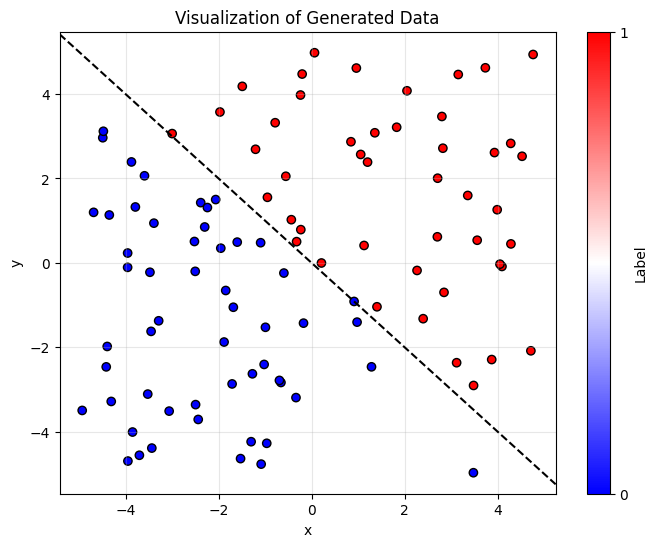

In [38]:
# Plotting the data

data_arr = np.array(data)
x_vals = data_arr[:, 0]
y_vals = data_arr[:, 1]
labels = data_arr[:, 2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_vals, y_vals, c=labels, cmap='bwr', edgecolor='k')

plt.axline((0, 0), slope=-1, color='black', linestyle='--', label='Decision Boundary')
plt.colorbar(scatter, ticks=[0, 1], label='Label')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Visualization of Generated Data')
plt.grid(True, alpha=0.3)
plt.show()

###Defining the Functions



*   Defining the sigmoid function.
*   Creating the predict function that returns what the model predicts.



In [39]:
# Helper functions

def sigmoid(x):
    return expit(x)

def predict(x, y, w0, w1, w2):
    z = w0 + w1*x + w2*y
    return sigmoid(z)

###Intitialising the variables

* Setting the initial weights to 0
* Setting the loss array to a the empty set
* Setting the learning rate and the epochs

In [52]:
# Intitialisation

w0 = 0
w1 = 0
w2 = 0

loss_arr = []

learning_rate = 0.05
epochs = 100

##Main loop

###Learning Loop

Trains the model and plots the loss over time for each epoch.

In [53]:
for i in range(epochs):
    epoch_loss = 0

    for x, y, label in data_arr:

        pred = predict(x, y, w0, w1, w2)
        loss = label - pred
        epoch_loss += abs(loss)

        w0 += learning_rate * loss * 1
        w1 += learning_rate * loss * x
        w2 += learning_rate * loss * y

    loss_arr.append(epoch_loss / data_size)

###Plotting the data

w0: 0.3812034881777745
w1: 4.596811350745275
w2: 4.91717506973041


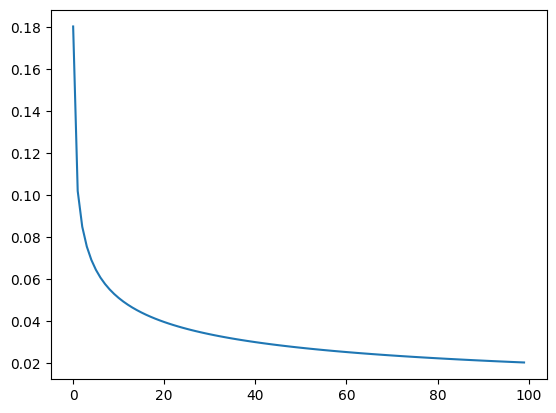

In [54]:
# Weights
print(f'w0: {w0}')
print(f'w1: {w1}')
print(f'w2: {w2}')

# Loss
plt.plot(loss_arr)

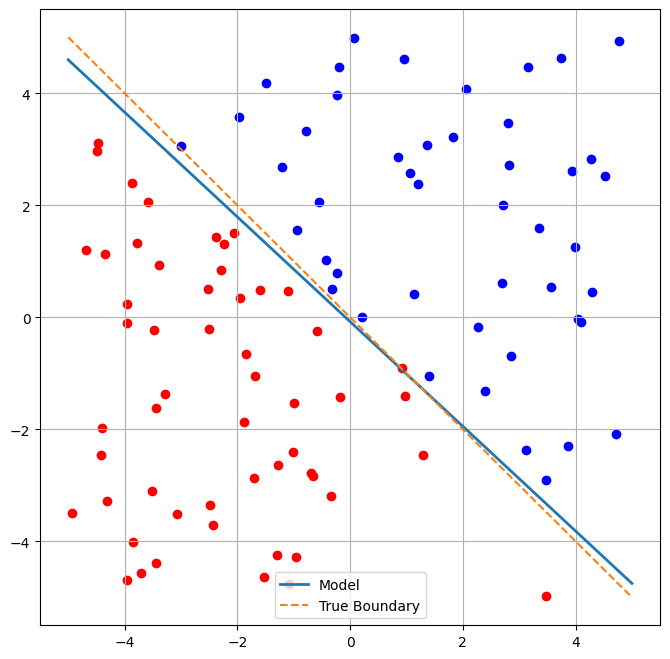

In [55]:
# Model
plt.figure(figsize=(8, 8))

for x, y, label in data:
    if label == 0:
        plt.scatter(x, y, color="red")
    else:
        plt.scatter(x, y, color="blue")

x_line = np.linspace(-5, 5, 100)
y_line = -(w0 + w1 * x_line) / w2

plt.plot(x_line, y_line, linewidth=2, label="Model")
plt.plot(x_line, -x_line, "--", label="True Boundary")

plt.legend()
plt.grid()
plt.show()